Loading original.wav and karaoke.wav...


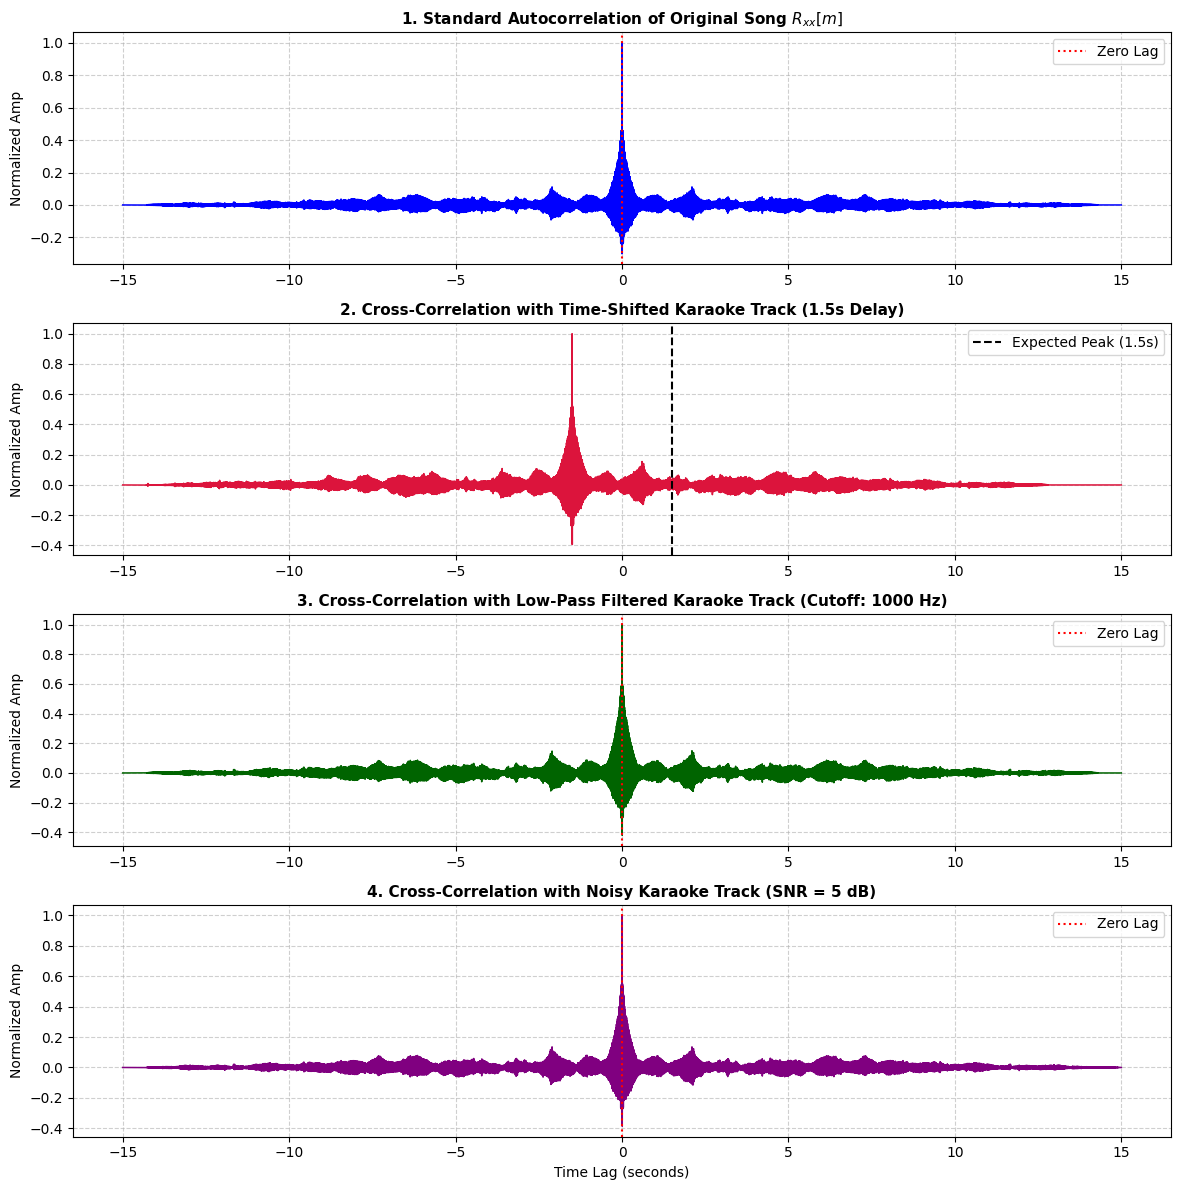

In [6]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def analyze_parameters_and_analyze(file_orig, file_kar, sr=22050, duration=15):
    print(f"Loading {file_orig} and {file_kar}...")
    x, _ = librosa.load(file_orig, sr=sr, mono=True, duration=duration)
    y, _ = librosa.load(file_kar, sr=sr, mono=True, duration=duration)

    min_len = min(len(x), len(y))
    x = x[:min_len]
    y = y[:min_len]

    x = x / np.max(np.abs(x))
    y = y / np.max(np.abs(y))

    delay_sec = 1.5
    delay_samples = int(delay_sec * sr)
    y_delayed = np.pad(y, (delay_samples, 0))[:min_len]

    b, a = signal.butter(4, 1000 / (sr / 2), btype='low')
    y_filtered = signal.filtfilt(b, a, y)

    snr_db = 5  
    signal_power = np.mean(y ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(y))
    y_noisy = y + noise

    def get_norm_corr(sig1, sig2):
        corr = signal.fftconvolve(sig1, sig2[::-1], mode='full')
        return corr / np.max(np.abs(corr))

    r_xx = get_norm_corr(x, x)

    r_xy_delayed = get_norm_corr(x, y_delayed)
    r_xy_filtered = get_norm_corr(x, y_filtered)
    r_xy_noisy = get_norm_corr(x, y_noisy)

    time_lags = np.arange(-min_len + 1, min_len) / sr

    plt.figure(figsize=(12, 12))

    plt.subplot(4, 1, 1)
    plt.plot(time_lags, r_xx, color='b', linewidth=1.1)
    plt.axvline(0, color='r', linestyle=':', label='Zero Lag')
    plt.title("1. Standard Autocorrelation of Original Song $R_{xx}[m]$", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(time_lags, r_xy_delayed, color='crimson', linewidth=1.1)
    plt.axvline(delay_sec, color='black', linestyle='--', label=f'Expected Peak ({delay_sec}s)')
    plt.title(f"2. Cross-Correlation with Time-Shifted Karaoke Track (1.5s Delay)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(time_lags, r_xy_filtered, color='darkgreen', linewidth=1.1)
    plt.axvline(0, color='r', linestyle=':', label='Zero Lag')
    plt.title("3. Cross-Correlation with Low-Pass Filtered Karaoke Track (Cutoff: 1000 Hz)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()


    plt.subplot(4, 1, 4)
    plt.plot(time_lags, r_xy_noisy, color='purple', linewidth=1.1)
    plt.axvline(0, color='r', linestyle=':', label='Zero Lag')
    plt.title("4. Cross-Correlation with Noisy Karaoke Track (SNR = 5 dB)", fontsize=11, fontweight='bold')
    plt.xlabel("Time Lag (seconds)")
    plt.ylabel("Normalized Amp")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_parameters_and_analyze("original.wav", "karaoke.wav")